# 🔢 MNIST Digit Recognizer — CNN with TensorFlow/Keras

[![Kaggle](https://img.shields.io/badge/Kaggle-Competition-20BEFF?logo=kaggle)](https://www.kaggle.com/competitions/digit-recognizer)
[![Python](https://img.shields.io/badge/Python-3.10%2B-3776AB?logo=python)](https://www.python.org/)
[![TensorFlow](https://img.shields.io/badge/TensorFlow-2.x-FF6F00?logo=tensorflow)](https://www.tensorflow.org/)

---

## Overview

This notebook builds a **Convolutional Neural Network (CNN)** to classify handwritten digits from the classic [MNIST dataset](http://yann.lecun.com/exdb/mnist/), as hosted on Kaggle's *Digit Recognizer* competition.

### Dataset
- **42,000** labeled training images (28×28 grayscale)
- **28,000** unlabeled test images for submission
- **10 classes**: digits 0–9

### Approach
| Stage | Detail |
|---|---|
| Preprocessing | Normalization + reshape for CNN input |
| Architecture | 2× Conv2D → MaxPool → Dense → Softmax |
| Regularization | Dropout (0.5) before classifier |
| Optimizer | Adam |
| Loss | Sparse Categorical Cross-Entropy |
| Epochs | 10 |


---
## 1. Setup & Imports

Standard data science stack plus TensorFlow/Keras for model building.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version:      {np.__version__}")
print(f"Pandas version:     {pd.__version__}")


TensorFlow version: 2.21.0
NumPy version:      2.2.0
Pandas version:     2.2.3


---
## 2. Load Data

The Kaggle dataset ships as two flat CSVs where each row is one image:
- `train.csv` — 42,000 rows × 785 columns (`label` + 784 pixel values)
- `test.csv`  — 28,000 rows × 784 columns (no label column)

Each pixel value is an integer in **[0, 255]** representing grayscale intensity.


In [2]:
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")
train.head()


Train shape: (42000, 785)
Test shape:  (28000, 784)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


---
## 3. Exploratory Data Analysis

Before building anything, let's get a feel for the data — class distribution and what the images actually look like.


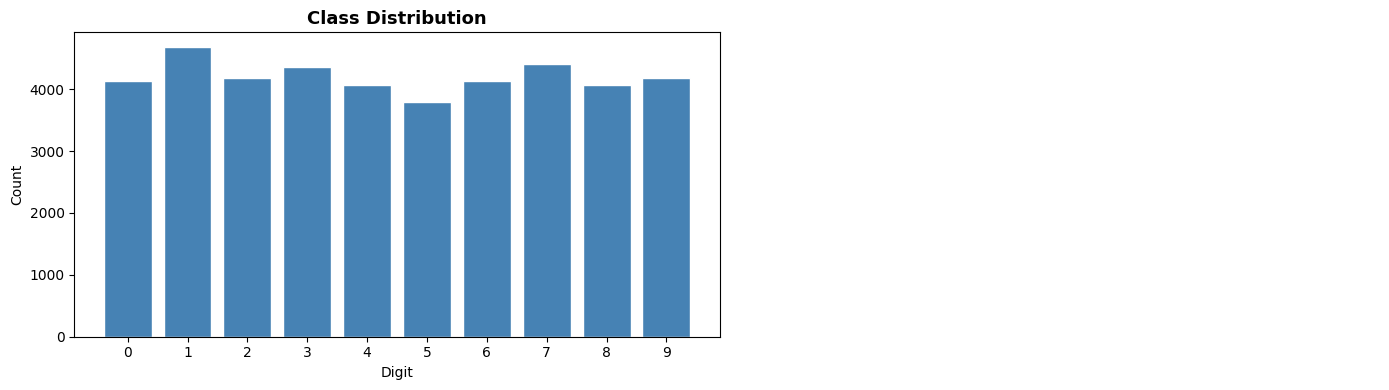

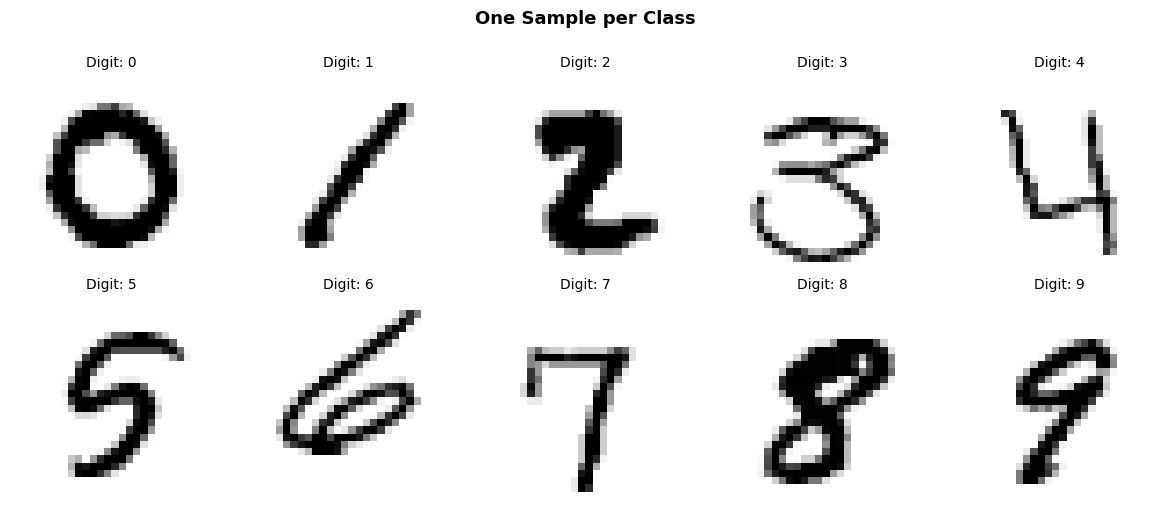

Class counts:
label
0    4132
1    4684
2    4177
3    4351
4    4072
5    3795
6    4137
7    4401
8    4063
9    4188


In [3]:
# ── Class distribution ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart
label_counts = train['label'].value_counts().sort_index()
axes[0].bar(label_counts.index, label_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Digit')
axes[0].set_ylabel('Count')
axes[0].set_xticks(range(10))

# Sample images — one per digit
axes[1].axis('off')
fig2, sample_axes = plt.subplots(2, 5, figsize=(12, 5))
for digit in range(10):
    idx  = train[train['label'] == digit].index[0]
    img  = train.iloc[idx, 1:].values.reshape(28, 28)
    ax   = sample_axes[digit // 5][digit % 5]
    ax.imshow(img, cmap='gray_r')
    ax.set_title(f'Digit: {digit}', fontsize=10)
    ax.axis('off')

fig.tight_layout()
fig2.suptitle('One Sample per Class', fontsize=13, fontweight='bold', y=1.01)
fig2.tight_layout()
plt.show()

print("Class counts:")
print(label_counts.to_string())


---
## 4. Preprocessing

Two operations are required before feeding images into a CNN:

1. **Normalize** pixel values from `[0, 255]` → `[0.0, 1.0]`  
   This keeps gradients stable during training and speeds up convergence.

2. **Reshape** from `(N, 784)` → `(N, 28, 28, 1)`  
   Keras Conv2D layers expect `(batch, height, width, channels)`.  
   MNIST is grayscale so `channels = 1`.


In [4]:
# Separate features and labels
X_train = train.drop('label', axis=1).values
y_train = train['label'].values
X_test  = test.values

# Normalize: [0, 255] → [0.0, 1.0]
X_train = X_train / 255.0
X_test  = X_test  / 255.0

# Reshape: (N, 784) → (N, 28, 28, 1)  [height, width, channels]
X_train = X_train.reshape(-1, 28, 28, 1)
X_test  = X_test.reshape(-1, 28, 28, 1)

print(f"X_train: {X_train.shape}  |  dtype: {X_train.dtype}")
print(f"X_test:  {X_test.shape}   |  dtype: {X_test.dtype}")
print(f"y_train: {y_train.shape}  |  classes: {np.unique(y_train)}")


X_train: (42000, 28, 28, 1)  |  dtype: float64
X_test:  (28000, 28, 28, 1)   |  dtype: float64
y_train: (42000,)  |  classes: [0 1 2 3 4 5 6 7 8 9]


---
## 5. Model Architecture

The network follows a standard **Conv → Pool → Conv → Pool → FC** pattern:

```
Input (28×28×1)
    │
    ├─ Conv2D(32, 3×3, ReLU)   → 26×26×32
    ├─ MaxPooling2D(2×2)        → 13×13×32
    │
    ├─ Conv2D(64, 3×3, ReLU)   → 11×11×64
    ├─ MaxPooling2D(2×2)        →  5×5×64
    │
    ├─ Flatten()                → 1600
    ├─ Dense(128, ReLU)
    ├─ Dropout(0.5)             ← regularization
    └─ Dense(10, Softmax)       → class probabilities
```

**Design choices:**
- Doubling filters (32 → 64) lets later layers detect more abstract features.
- `MaxPooling2D` halves spatial dimensions, reducing parameters and adding translation invariance.
- `Dropout(0.5)` before the classifier prevents co-adaptation of dense neurons.


In [5]:
model = models.Sequential([
    # ── Block 1 ───────────────────────────────────────────────────────────
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    # ── Block 2 ───────────────────────────────────────────────────────────
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # ── Classifier ────────────────────────────────────────────────────────
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),           # regularization
    layers.Dense(10, activation='softmax'),
])

model.summary()


C:\Users\khale\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

---
## 6. Training

| Hyperparameter | Value | Rationale |
|---|---|---|
| Optimizer | Adam | Adaptive LR; robust default |
| Loss | Sparse Categorical Cross-Entropy | Integer labels, multi-class |
| Batch size | 32 | Balance between speed and gradient noise |
| Epochs | 10 | Sufficient for convergence on MNIST |
| Validation split | 10% | ~4,200 samples held out for monitoring |


In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)


Epoch 1/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.9217 - loss: 0.2539 - val_accuracy: 0.9774 - val_loss: 0.0653
Epoch 2/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.9719 - loss: 0.0916 - val_accuracy: 0.9862 - val_loss: 0.0421
Epoch 3/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.9792 - loss: 0.0678 - val_accuracy: 0.9855 - val_loss: 0.0453
Epoch 4/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.9838 - loss: 0.0538 - val_accuracy: 0.9879 - val_loss: 0.0362
Epoch 5/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.9869 - loss: 0.0437 - val_accuracy: 0.9898 - val_loss: 0.0330
Epoch 6/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.9879 - loss: 0.0388 - val_accuracy: 0.9905 - val_loss: 0.0286
Epoch 7/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 67s 56ms/step - accuracy: 0.9895 - loss: 0.0316 - val_accuracy: 0.9881 - val_loss: 0.0419
Epoch 8/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.9907 -

---
## 7. Evaluation

### 7.1 Training Curves
Plotting accuracy and loss across epochs reveals overfitting, underfitting, or healthy convergence.


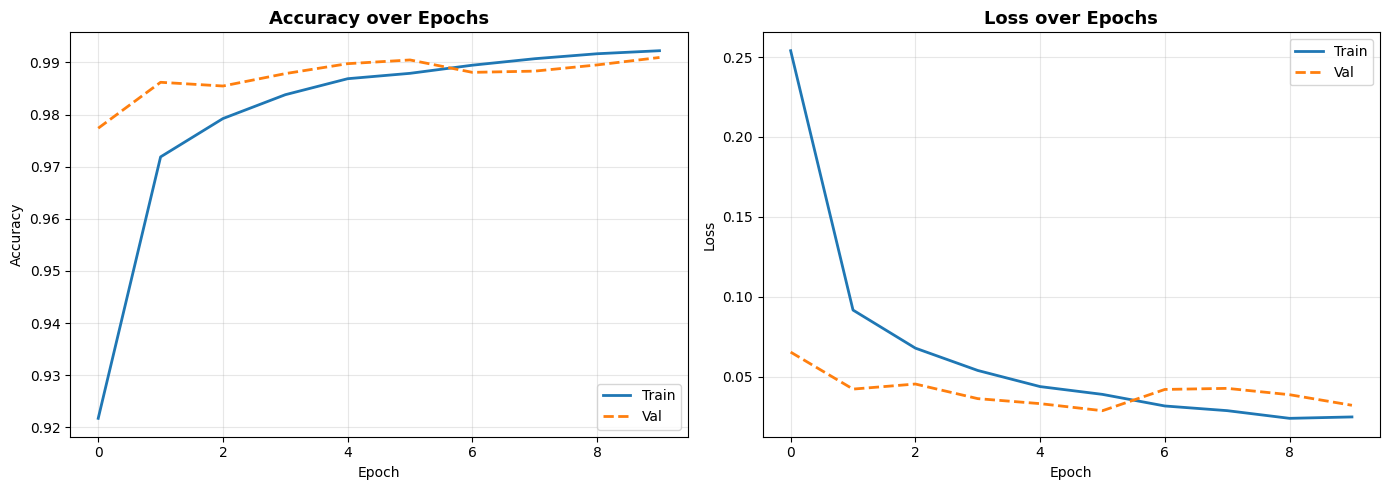

Final Train Accuracy: 0.9922
Final Val   Accuracy: 0.9910


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val',   linewidth=2, linestyle='--')
axes[0].set_title('Accuracy over Epochs', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(history.history['loss'],     label='Train', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val',   linewidth=2, linestyle='--')
axes[1].set_title('Loss over Epochs', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

final_train_acc = history.history['accuracy'][-1]
final_val_acc   = history.history['val_accuracy'][-1]
print(f"Final Train Accuracy: {final_train_acc:.4f}")
print(f"Final Val   Accuracy: {final_val_acc:.4f}")


### 7.2 Confusion Matrix

The confusion matrix shows which digits the model confuses most often — a useful diagnostic beyond raw accuracy.


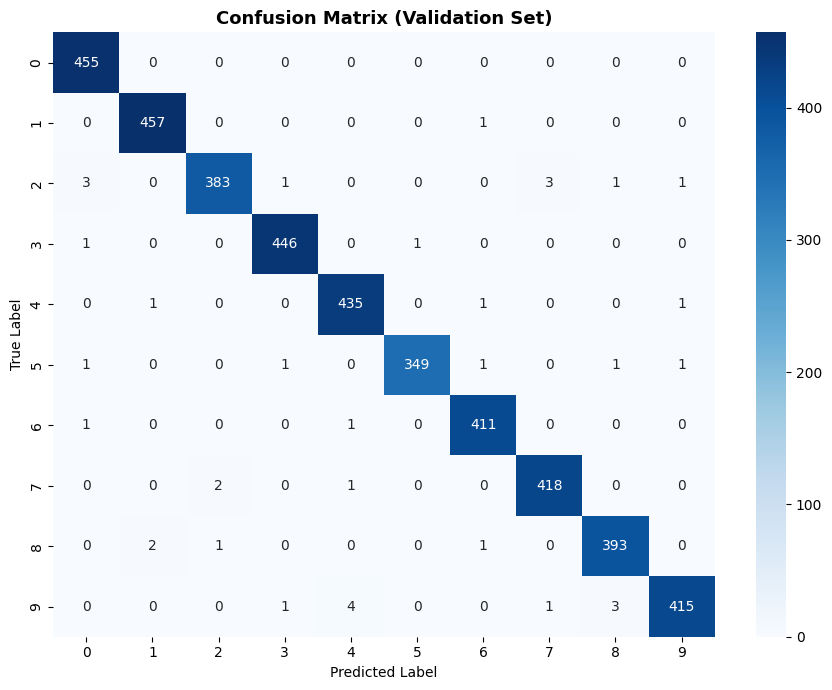

In [8]:
# Run predictions on the validation split (last 10% of training data)
val_size   = int(len(X_train) * 0.1)
X_val      = X_train[-val_size:]
y_val      = y_train[-val_size:]

val_preds  = np.argmax(model.predict(X_val, verbose=0), axis=1)
cm         = confusion_matrix(y_val, val_preds)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=range(10), yticklabels=range(10),
    ax=ax
)
ax.set_title('Confusion Matrix (Validation Set)', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.show()


### 7.3 Sample Predictions

A visual sanity check — green border = correct, red border = incorrect.


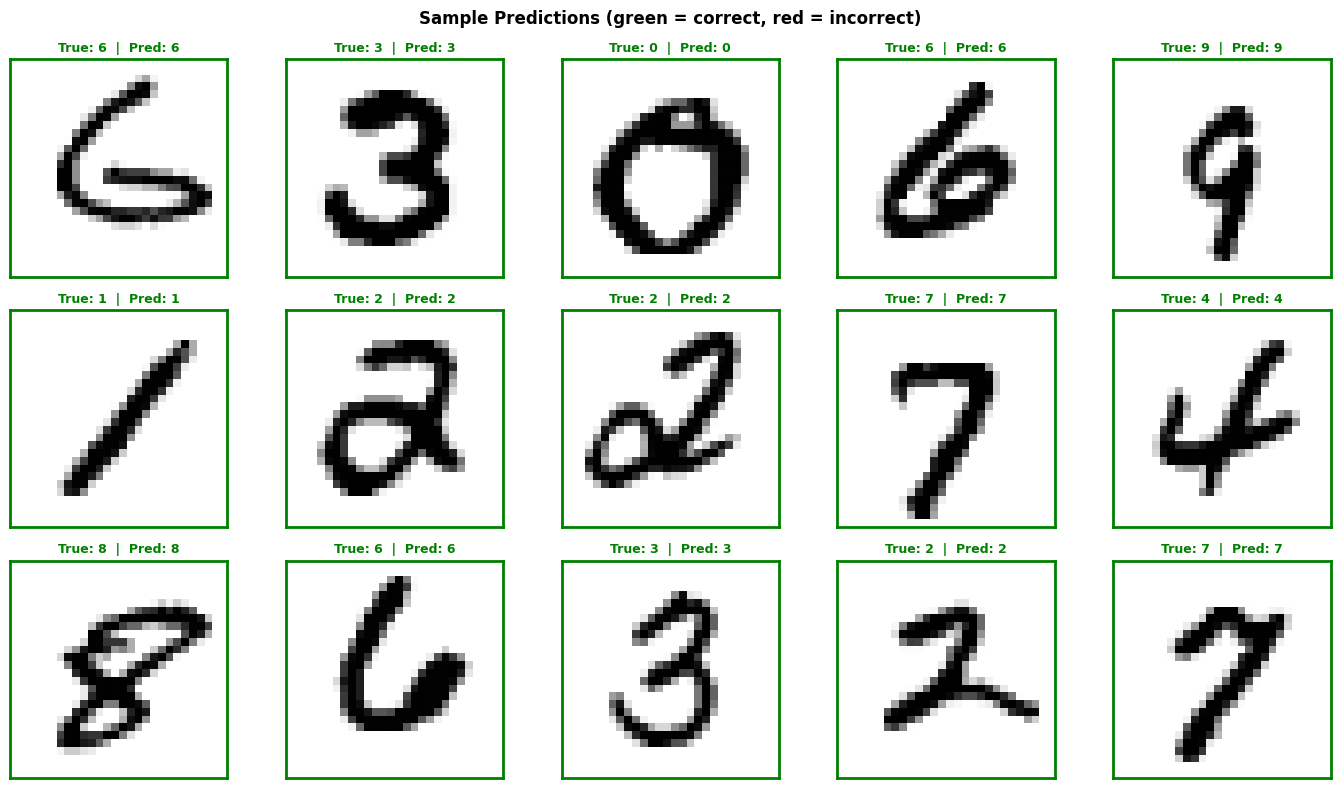

In [9]:
n_samples = 15
indices   = np.random.choice(len(X_val), n_samples, replace=False)

fig, axes = plt.subplots(3, 5, figsize=(14, 8))
for i, idx in enumerate(indices):
    ax      = axes[i // 5][i % 5]
    true_l  = y_val[idx]
    pred_l  = val_preds[idx]
    correct = true_l == pred_l

    ax.imshow(X_val[idx].reshape(28, 28), cmap='gray_r')
    ax.set_title(f'True: {true_l}  |  Pred: {pred_l}',
                 fontsize=9,
                 color='green' if correct else 'red',
                 fontweight='bold')
    color = 'green' if correct else 'red'
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(2)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle('Sample Predictions (green = correct, red = incorrect)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 8. Generate Submission

Run inference on the 28,000 test images and format the output for Kaggle submission.

Expected format:
```
ImageId,Label
1,2
2,0
...
```


In [10]:
# Predict on test set
test_probs  = model.predict(X_test, verbose=1)   # shape: (28000, 10)
test_labels = np.argmax(test_probs, axis=1)       # take argmax over class axis

# Build submission DataFrame
submission = pd.DataFrame({
    'ImageId': range(1, len(test_labels) + 1),
    'Label':   test_labels
})

submission.to_csv('submission.csv', index=False)

print(f"Submission saved: {len(submission):,} rows")
print()
print(submission.head(10))


875/875 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step
Submission saved: 28,000 rows

   ImageId  Label
0        1      2
1        2      0
2        3      9
3        4      0
4        5      3
5        6      7
6        7      0
7        8      3
8        9      0
9       10      3


---
## 9. Potential Improvements

| Technique |
|---|
| **Data Augmentation** (rotation, zoom, shift) |
| **Batch Normalization** after Conv layers |
| **Learning Rate Scheduling** (ReduceLROnPlateau) |
| **Deeper architecture** (3+ conv blocks) |
| **Ensemble** of multiple CNN runs |
